# K-Nearest Neighbors (KNN) adaptado a `penguins.csv`

## Objetivo
Adaptar el notebook original basado en **Iris** para clasificar especies de pingüinos usando tu archivo **penguins.csv**.

Además, en este caso agregamos una mejora importante: **escalado de variables**, porque KNN sí depende mucho de la distancia entre atributos.


## Bloque 1. Importar librerías

Se cargan las herramientas necesarias para:
- leer y limpiar el CSV,
- codificar la variable objetivo,
- escalar variables,
- entrenar KNN,
- evaluar el modelo,
- y visualizar fronteras de decisión.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Bloque 2. Cargar el CSV y revisar la estructura

In [ ]:
possible_paths = [
    Path("penguins.csv"),
    Path("/mnt/data/penguins.csv")
]

csv_path = None
for p in possible_paths:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("No se encontró el archivo penguins.csv")

df = pd.read_csv(csv_path)

print("Archivo cargado desde:", csv_path)
print("Shape del dataset:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nPrimeras 5 filas:")
display(df.head())

Archivo cargado desde: penguins.csv
Shape del dataset: (344, 9)

Columnas:
['Unnamed: 0', 'species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']

Primeras 5 filas:


,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## Bloque 3. Limpiar la data

Quitamos la columna `Unnamed: 0` y eliminamos filas con nulos en las variables necesarias.


In [ ]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

feature_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
target_col = "species"

data = df[feature_cols + [target_col]].copy()

print("Valores faltantes antes de limpiar:")
print(data.isna().sum())

data = data.dropna().reset_index(drop=True)

print("\nShape luego de limpiar:", data.shape)
print("\nValores faltantes después de limpiar:")
print(data.isna().sum())

display(data.head())

Valores faltantes antes de limpiar:
bill_length_mm       2
bill_depth_mm        2
flipper_length_mm    2
body_mass_g          2
species              0
dtype: int64

Shape luego de limpiar: (342, 5)

Valores faltantes después de limpiar:
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
species              0
dtype: int64


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,39.1,18.7,181.0,3750.0,Adelie
1,39.5,17.4,186.0,3800.0,Adelie
2,40.3,18.0,195.0,3250.0,Adelie
3,36.7,19.3,193.0,3450.0,Adelie
4,39.3,20.6,190.0,3650.0,Adelie


### Error corregido aquí

KNN tampoco acepta nulos en `X`, así que sin esta limpieza aparecería un error de tipo `ValueError: Input X contains NaN`.


## Bloque 4. Codificar la variable objetivo

Transformamos `species` a etiquetas numéricas.


In [ ]:
label_encoder = LabelEncoder()
data["species_label"] = label_encoder.fit_transform(data[target_col])

X = data[feature_cols].values
y = data["species_label"].values
class_names = label_encoder.classes_

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Clases:", list(class_names))

print("\nPrimeras 5 observaciones de X:")
print(X[:5])

print("\nPrimeras 5 etiquetas de y:")
print(y[:5])

Shape de X: (342, 4)
Shape de y: (342,)
Clases: ['Adelie', 'Chinstrap', 'Gentoo']

Primeras 5 observaciones de X:
[[  39.1   18.7  181.  3750. ]
 [  39.5   17.4  186.  3800. ]
 [  40.3   18.   195.  3250. ]
 [  36.7   19.3  193.  3450. ]
 [  39.3   20.6  190.  3650. ]]

Primeras 5 etiquetas de y:
[0 0 0 0 0]


## Bloque 5. Visualizar dos variables

Usamos:
- `bill_length_mm`
- `bill_depth_mm`

Solo para inspección visual.


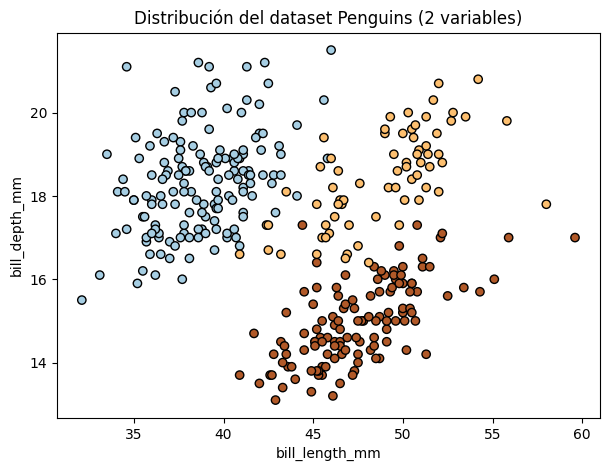

In [ ]:
X_vis = data[["bill_length_mm", "bill_depth_mm"]].values

_, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=y,
    cmap="Paired",
    edgecolors="k"
)

ax.set_title("Distribución del dataset Penguins (2 variables)")
ax.set_xlabel("bill_length_mm")
ax.set_ylabel("bill_depth_mm")
plt.show()

## Bloque 6. Dividir datos en entrenamiento y prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_train: (239, 4)
Shape de X_test: (103, 4)
Shape de y_train: (239,)
Shape de y_test: (103,)


## Bloque 7. Crear y entrenar KNN

### Ajuste importante
En Iris muchas veces se entrena KNN sin escalado porque es un ejercicio didáctico.  
Con `penguins.csv`, una variable como `body_mass_g` tiene una escala muy superior a las demás, así que conviene usar `StandardScaler`.

Para evitar fugas de información, el escalado y el modelo se integran en un **Pipeline**.


In [ ]:
k = 5

knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean"
    ))
])

knn.fit(X_train, y_train)

print(f"Modelo KNN entrenado correctamente con k = {k}")

Modelo KNN entrenado correctamente con k = 5


## Bloque 8. Predicciones y evaluación

In [ ]:
y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=class_names)

print("Accuracy:", acc)
print("\nMatriz de confusión:")
print(cm)
print("\nReporte de clasificación:")
print(report)

Accuracy: 1.0

Matriz de confusión:
[[45  0  0]
 [ 0 21  0]
 [ 0  0 37]]

Reporte de clasificación:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        45
   Chinstrap       1.00      1.00      1.00        21
      Gentoo       1.00      1.00      1.00        37

    accuracy                           1.00       103
   macro avg       1.00      1.00      1.00       103
weighted avg       1.00      1.00      1.00       103



## Bloque 9. Fronteras de decisión en 2D

Para dibujar el plano, entrenamos otro KNN solo con 2 variables visuales.  
También aquí escalamos antes de clasificar.


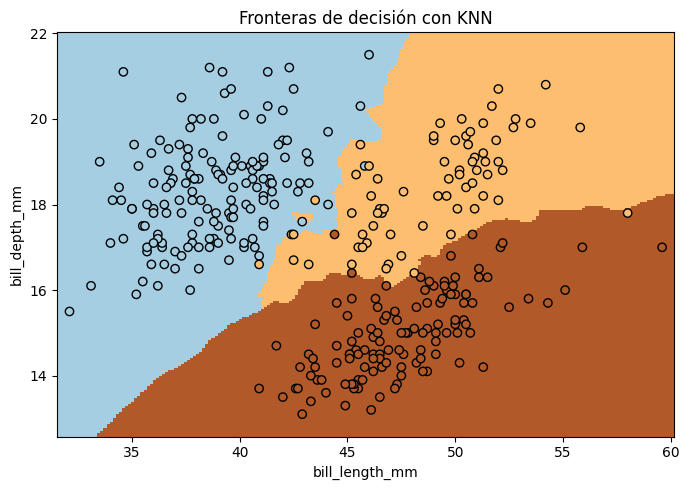

In [ ]:
knn_vis = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5, metric="euclidean"))
])

knn_vis.fit(X_vis, y)

offset = 0.5
x_min, x_max = X_vis[:, 0].min() - offset, X_vis[:, 0].max() + offset
y_min, y_max = X_vis[:, 1].min() - offset, X_vis[:, 1].max() + offset

x_grid, y_grid = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

pred_grid = knn_vis.predict(np.c_[x_grid.ravel(), y_grid.ravel()])
pred_grid = pred_grid.reshape(x_grid.shape)

_, ax = plt.subplots(figsize=(7, 5))
ax.pcolormesh(x_grid, y_grid, pred_grid, cmap="Paired", shading="auto")
ax.scatter(X_vis[:, 0], X_vis[:, 1], c=y, cmap="Paired", edgecolors="k")

ax.set_title("Fronteras de decisión con KNN")
ax.set_xlabel("bill_length_mm")
ax.set_ylabel("bill_depth_mm")

plt.tight_layout()
plt.show()

## Bloque 10. Probar con un nuevo pingüino

In [ ]:
nuevo_pinguino = np.array([[46.0, 14.5, 215.0, 5000.0]])

pred_nuevo = knn.predict(nuevo_pinguino)[0]
prob_nuevo = knn.predict_proba(nuevo_pinguino)[0]

print("Nuevo pingüino:", nuevo_pinguino)
print("Clase predicha:", pred_nuevo)
print("Especie predicha:", class_names[pred_nuevo])

print("\nProbabilidades por clase:")
for i, prob in enumerate(prob_nuevo):
    print(f"  {class_names[i]}: {prob:.6f}")

Nuevo pingüino: [[  46.    14.5  215.  5000. ]]
Clase predicha: 2
Especie predicha: Gentoo

Probabilidades por clase:
  Adelie: 0.000000
  Chinstrap: 0.000000
  Gentoo: 1.000000


## Conclusión

Este notebook quedó adaptado a tu dataset y corregido para un uso más realista de KNN.

Los cambios más importantes fueron:
1. cargar el CSV en vez de `load_iris()`,
2. eliminar `Unnamed: 0`,
3. limpiar nulos,
4. codificar `species`,
5. escalar variables antes de aplicar KNN.
